# Recurrent Excitatory–Inhibitory Neural Network

## Objective

Explore how inhibitory synaptic strength changes firing intensity, excitation–inhibition coupling, and population rhythms in a small recurrent spiking network. A self-contained simulation compares three inhibition levels while holding network connectivity fixed.


In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.fft import rfft, rfftfreq

In [52]:
def get_default_params():
    """
    Default parameters for the recurrent E-I LIF network.

    The default w_GABA value is set to 2.0 nS and is later varied during parameter exploration.

    """
    return {
        "N_E": 20,
        "N_I": 10,

        "dt": 0.1,           # ms
        "T": 1200.0,         # ms; includes 100 ms pre-input and 200 ms post-input

        "tau_m": 20.0,       # ms
        "V_rest": -70.0,     # mV
        "V_th": -55.0,       # mV
        "V_reset": -75.0,    # mV
        "R": 1.0,

        "tau_AMPA": 5.0,     # ms
        "tau_GABA": 10.0,    # ms

        "w_AMPA": 0.5,       # nS
        "w_GABA": 2.0,       # nS; default value, explored later

        "E_AMPA": 0.0,       # mV
        "E_GABA": -70.0,     # mV

        "p_conn": 0.5,

        "I_ext_amp": 50.0,    # nA; external input to excitatory neurons
        "I_ext_on": 100.0,   # ms
        "I_ext_off": 1000.0, # ms

        "refractory_ms": 2.0,

        "connectivity_seed": 42,
        "simulation_seed": 1,
    }


params = get_default_params()
params

{'N_E': 20,
 'N_I': 10,
 'dt': 0.1,
 'T': 1200.0,
 'tau_m': 20.0,
 'V_rest': -70.0,
 'V_th': -55.0,
 'V_reset': -75.0,
 'R': 1.0,
 'tau_AMPA': 5.0,
 'tau_GABA': 10.0,
 'w_AMPA': 0.5,
 'w_GABA': 2.0,
 'E_AMPA': 0.0,
 'E_GABA': -70.0,
 'p_conn': 0.5,
 'I_ext_amp': 50.0,
 'I_ext_on': 100.0,
 'I_ext_off': 1000.0,
 'refractory_ms': 2.0,
 'connectivity_seed': 42,
 'simulation_seed': 1}

## Methods

### Network and membrane dynamics

The network contains 20 excitatory and 10 inhibitory leaky integrate-and-fire neurons. Boolean connectivity matrices encode AMPA and GABA projections onto both populations. Connections are sampled with probability 0.5, and recurrent self-connections are removed. Topology and synaptic strength are represented separately.

AMPA and GABA conductances decay exponentially and increase after presynaptic spikes. Synaptic currents use conductance multiplied by the reversal-potential driving force, with positive current defined as depolarizing. Euler integration advances membrane voltage; threshold crossings trigger a reset and a short refractory period.

Dense Boolean matrices are practical for this 30-neuron model. A sparse representation would be an implementation option for larger networks.


In [53]:
def create_connectivity(params, seed=None):
    """
    Create random recurrent AMPA and GABA connectivity matrices.

    The connectivity is represented by binary Boolean matrices.
    Each entry indicates whether a synaptic connection exists.

    C_AMPA has shape (N_post, N_E_pre):
    - rows = postsynaptic neurons
    - columns = excitatory presynaptic neurons
    - nonzero entries represent E -> E and E -> I AMPA-mediated connections

    C_GABA has shape (N_post, N_I_pre):
    - rows = postsynaptic neurons
    - columns = inhibitory presynaptic neurons
    - nonzero entries represent I -> E and I -> I GABA-mediated connections

    This representation separates network topology from synaptic strength.
    The topology is fixed by p_conn, whereas w_AMPA and w_GABA are applied later
    when presynaptic spikes increase postsynaptic conductances.

    """
    N_E = params["N_E"]
    N_I = params["N_I"]
    N = N_E + N_I
    p = params["p_conn"]

    rng = np.random.default_rng(params["connectivity_seed"] if seed is None else seed)

    # Each possible connection is sampled from a Bernoulli distribution with probability p.
    # True means a connection exists; False means no connection.
    C_AMPA = rng.random((N, N_E)) < p
    C_GABA = rng.random((N, N_I)) < p

    # Remove self-connections only within same-population recurrent blocks:
    # E_i -> E_i in the E->E block, and I_i -> I_i in the I->I block.
    for i in range(N_E):
        C_AMPA[i, i] = False

    for i in range(N_I):
        C_GABA[N_E + i, i] = False

    return {
    "C_AMPA": C_AMPA,
    "C_GABA": C_GABA,
}

In [54]:
def simulate_network(params, connectivity=None, w_GABA=None, seed=None):
    """
    Simulate the recurrent E-I network using Euler's method.

    The simulation implements:
    - LIF membrane dynamics
    - AMPA single-exponential conductance
    - GABA single-exponential conductance
    - spike detection and reset
    - external input only to E neurons
    """
    p = params.copy()

    if w_GABA is not None:
        p["w_GABA"] = float(w_GABA)

    N_E = p["N_E"]
    N_I = p["N_I"]
    N = N_E + N_I

    dt = p["dt"]
    T = p["T"]
    n_steps = int(np.round(T / dt)) + 1
    time = np.arange(n_steps) * dt

    if connectivity is None:
        connectivity = create_connectivity(p)

    C_AMPA = connectivity["C_AMPA"]
    C_GABA = connectivity["C_GABA"]

    rng = np.random.default_rng(p["simulation_seed"] if seed is None else seed)

    # Initial membrane potentials: near resting potential with small random perturbations.
    # V stores the current membrane potential of all neurons.
    # The first N_E entries correspond to excitatory neurons, and the remaining N_I entries correspond to inhibitory neurons.
    V = np.full(N, p["V_rest"], dtype=float) + rng.normal(0.0, 1.0, size=N)

    # Conductances per postsynaptic neuron.
    g_AMPA = np.zeros(N, dtype=float)
    g_GABA = np.zeros(N, dtype=float)

    refractory_remaining = np.zeros(N, dtype=float)

    # Last spike time for each neuron.
    # -np.inf means that the neuron has not fired yet.
    last_spike_time = np.full(N, -np.inf, dtype=float)

    # Record variables.
    V_record = np.zeros((n_steps, N), dtype=float)

    # g_AMPA and g_GABA store the total incoming AMPA/GABA conductance for each postsynaptic neuron.
    # Conductances are postsynaptic variables because each neuron receives summed input from many presynaptic neurons.
    g_AMPA_record = np.zeros((n_steps, N), dtype=float)
    g_GABA_record = np.zeros((n_steps, N), dtype=float)

    I_ext_record = np.zeros((n_steps, N), dtype=float)
    I_AMPA_record = np.zeros((n_steps, N), dtype=float)
    I_GABA_record = np.zeros((n_steps, N), dtype=float)
    I_total_record = np.zeros((n_steps, N), dtype=float)

    spike_times = []
    spike_ids = []

    for ti, t in enumerate(time):

        # ------------------------------------------------------------
        # 1. Single-exponential synaptic conductance decay
        # ------------------------------------------------------------
        # dg/dt = -g/tau.
        # Spike-triggered conductance increments are added later after spike detection.
        g_AMPA += dt * (-g_AMPA / p["tau_AMPA"])
        g_GABA += dt * (-g_GABA / p["tau_GABA"])

        g_AMPA = np.maximum(g_AMPA, 0.0)
        g_GABA = np.maximum(g_GABA, 0.0)

        # ------------------------------------------------------------
        # 2. External input: only to excitatory neurons
        # ------------------------------------------------------------
        # External current is applied only to excitatory neurons.
        # Inhibitory neurons receive no direct external input and are driven only by synaptic input.
        I_ext = np.zeros(N, dtype=float)

        if p["I_ext_on"] <= t < p["I_ext_off"]:
            I_ext[:N_E] = p["I_ext_amp"]


        # ------------------------------------------------------------
        # 3. Conductance-based synaptic currents
        # ------------------------------------------------------------
        # Sign convention for synaptic current:
        # An outward-positive convention writes the driving force as (V - E_rev).
        # Here, because positive I_total depolarizes the neuron in the LIF update,
        # synaptic input is implemented as g * (E_rev - V).
        #
        # Synaptic weights are already absorbed into g_AMPA and g_GABA
        # during spike-triggered conductance updates.
        # This makes AMPA depolarizing and GABA inhibitory through their reversal potentials.
        I_AMPA = g_AMPA * (p["E_AMPA"] - V)
        I_GABA = g_GABA * (p["E_GABA"] - V)

        I_total = I_ext + I_AMPA + I_GABA

        # ------------------------------------------------------------
        # 4. Euler update for LIF membrane potential
        # ------------------------------------------------------------
        # Euler update of the LIF equation:
        # V(t+dt) = V(t) + dt/tau_m * [-(V - V_rest) + R * I_total]
        active = refractory_remaining <= 0.0

        dV = (dt / p["tau_m"]) * (-(V - p["V_rest"]) + p["R"] * I_total)

        V[active] += dV[active]
        V[~active] = p["V_reset"]

        refractory_remaining[refractory_remaining > 0.0] -= dt
        refractory_remaining = np.maximum(refractory_remaining, 0.0)
        # Refractory period is included only to prevent unrealistically immediate repeated spikes.

        # ------------------------------------------------------------
        # 5. Spike detection and reset
        # ------------------------------------------------------------
        spiked = V >= p["V_th"]

        if np.any(spiked):
            ids = np.where(spiked)[0]

            spike_times.extend([t] * len(ids))
            spike_ids.extend(ids.tolist())

            # Update the last spike time array using the vectorized spike mask.
            last_spike_time[spiked] = t

            V[spiked] = p["V_reset"]

            if p["refractory_ms"] > 0:
                refractory_remaining[spiked] = p["refractory_ms"]

            # --------------------------------------------------------
            # 6. Spike-triggered synaptic conductance increments
            # --------------------------------------------------------
            # w_AMPA and w_GABA are applied here.
            # Therefore, g_AMPA and g_GABA store the total weighted incoming conductance
            # for each postsynaptic neuron
            E_spikes = spiked[:N_E].astype(float)
            I_spikes = spiked[N_E:].astype(float)

            if np.any(E_spikes):
                g_AMPA += p["w_AMPA"] * (C_AMPA @ E_spikes)

            if np.any(I_spikes):
                g_GABA += p["w_GABA"] * (C_GABA @ I_spikes)

        # ------------------------------------------------------------
        # 7. Record variables
        # ------------------------------------------------------------
        V_record[ti] = V
        g_AMPA_record[ti] = g_AMPA
        g_GABA_record[ti] = g_GABA

        I_ext_record[ti] = I_ext
        I_AMPA_record[ti] = I_AMPA
        I_GABA_record[ti] = I_GABA
        I_total_record[ti] = I_total

    return {
        "params": p,
        "connectivity": connectivity,
        "time": time,

        "V": V_record,
        "g_AMPA": g_AMPA_record,
        "g_GABA": g_GABA_record,

        "I_ext": I_ext_record,
        "I_AMPA": I_AMPA_record,
        "I_GABA": I_GABA_record,
        "I_total": I_total_record,

        "spike_times": np.array(spike_times, dtype=float),
        "spike_ids": np.array(spike_ids, dtype=int),
        "last_spike_time": last_spike_time,

    }

### Population and spectral measurements

Population firing rates use 10 ms bins. Normalized cross-correlation measures E–I coupling during stimulation, with positive lags indicating that excitation leads inhibition and negative lags indicating the reverse. Spectral analysis uses a more finely binned population-rate signal to resolve a wider frequency range.

Mean firing rates quantify activity levels. The coefficient of variation of the population rate serves as a synchrony proxy. FFT peak frequency and peak-to-background power ratio describe rhythmic structure. These measurements capture different aspects of the same dynamics.


In [55]:
def compute_population_rate(spike_times, spike_ids, neuron_ids, T, bin_ms=10.0):
    """
    Compute population firing rate using spike counts in fixed-width time bins.

    Rate unit:
    Hz = spikes / neuron / second
    """
    neuron_ids = np.array(list(neuron_ids), dtype=int)

    bins = np.arange(0.0, T + bin_ms, bin_ms)

    if spike_times.size == 0:
        counts = np.zeros(len(bins) - 1, dtype=float)
    else:
        mask = np.isin(spike_ids, neuron_ids)
        counts, _ = np.histogram(spike_times[mask], bins=bins)

    rate_hz = counts / (len(neuron_ids) * (bin_ms / 1000.0))
    centers = 0.5 * (bins[:-1] + bins[1:])

    return centers, rate_hz

In [56]:
def compute_cross_correlation(rate_E, rate_I, bin_ms=10.0, max_lag_ms=200.0):
    """
    Compute normalized cross-correlation between E and I population rates.

    Sign convention:
    - positive lag means E activity leads I activity
    - negative lag means I activity leads E activity
    - near-zero lag means E and I are nearly synchronous
    """
    x = np.asarray(rate_E, dtype=float)
    y = np.asarray(rate_I, dtype=float)

    x = x - np.mean(x)
    y = y - np.mean(y)

    if np.std(x) > 0:
        x = x / np.std(x)

    if np.std(y) > 0:
        y = y / np.std(y)

    max_lag_bins = int(np.round(max_lag_ms / bin_ms))
    lags_bins = np.arange(-max_lag_bins, max_lag_bins + 1)

    corr = np.zeros_like(lags_bins, dtype=float)

    for k, lag in enumerate(lags_bins):

        if lag < 0:
            xs = x[-lag:]
            ys = y[:lag]

        elif lag > 0:
            xs = x[:-lag]
            ys = y[lag:]

        else:
            xs = x
            ys = y

        if len(xs) > 1 and np.std(xs) > 0 and np.std(ys) > 0:
            corr[k] = np.mean(xs * ys)
        else:
            corr[k] = np.nan

    if np.all(np.isnan(corr)):
        peak_lag_ms = np.nan
        peak_corr = np.nan
    else:
        peak_idx = np.nanargmax(corr)
        peak_lag_ms = lags_bins[peak_idx] * bin_ms
        peak_corr = corr[peak_idx]

    return {
        "lags_ms": lags_bins * bin_ms,
        "corr": corr,
        "peak_lag_ms": peak_lag_ms,
        "peak_corr": peak_corr,
    }

In [57]:
def compute_fft_spectrum(rate, bin_ms=1.0, fmin=1.0, fmax=150.0):
    """
    Compute FFT spectrum of a population rate time series.

    FFT converts the population-rate time series from the time domain into the frequency domain.
    A clear peak suggests oscillatory activity.
    No clear peak suggests asynchronous-irregular or weakly rhythmic activity.
    """
    x = np.asarray(rate, dtype=float)
    x = x - np.mean(x)

    if len(x) < 4 or np.allclose(x, 0):
        return {
            "freqs": np.array([]),
            "power": np.array([]),
            "peak_freq_hz": np.nan,
            "peak_power": np.nan,
            "peak_ratio": np.nan,
        }

    fs = 1000.0 / bin_ms

    # Windowing reduces edge artifacts.
    window = np.hanning(len(x))

    spectrum = rfft(x * window)
    power = np.abs(spectrum) ** 2
    freqs = rfftfreq(len(x), d=1.0 / fs)

    search = (freqs >= fmin) & (freqs <= fmax)

    if np.any(search):
        idx_local = np.argmax(power[search])
        idx = np.where(search)[0][idx_local]

        peak_freq = freqs[idx]
        peak_power = power[idx]

        median_power = np.median(power[search]) + 1e-12
        peak_ratio = peak_power / median_power

    else:
        peak_freq = np.nan
        peak_power = np.nan
        peak_ratio = np.nan

    return {
        "freqs": freqs,
        "power": power,
        "peak_freq_hz": peak_freq,
        "peak_power": peak_power,
        "peak_ratio": peak_ratio,
    }

In [58]:
def analyze_result(result, rate_bin_ms=10.0, fft_bin_ms=1.0):
    """
    Compute:
    - E and I population rates using 10 ms bins
    - E/I cross-correlation
    - FFT spectrum of total population rate
    - mean firing rates during the external-input window
    - synchrony proxy based on total population-rate CV
    """
    p = result["params"]

    N_E = p["N_E"]
    N_I = p["N_I"]
    N = N_E + N_I
    T = p["T"]

    # 10 ms binned rates for plotting and cross-correlation.
    t_rate, rate_E = compute_population_rate(
        result["spike_times"],
        result["spike_ids"],
        np.arange(0, N_E),
        T,
        bin_ms=rate_bin_ms,
    )

    _, rate_I = compute_population_rate(
        result["spike_times"],
        result["spike_ids"],
        np.arange(N_E, N),
        T,
        bin_ms=rate_bin_ms,
    )

    _, rate_total_10 = compute_population_rate(
        result["spike_times"],
        result["spike_ids"],
        np.arange(0, N),
        T,
        bin_ms=rate_bin_ms,
    )

    # Mean firing rate during stimulation.
    stim_mask_spikes = (
        (result["spike_times"] >= p["I_ext_on"]) &
        (result["spike_times"] < p["I_ext_off"])
    )

    stim_duration_s = (p["I_ext_off"] - p["I_ext_on"]) / 1000.0
    spike_ids_stim = result["spike_ids"][stim_mask_spikes]

    mean_rate_E = np.sum(spike_ids_stim < N_E) / (N_E * stim_duration_s)
    mean_rate_I = np.sum(spike_ids_stim >= N_E) / (N_I * stim_duration_s)

    # Cross-correlation between E and I population rates.
    # It is computed during the stimulation window to reduce the influence
    # of shared silent periods before and after external input.
    stim_rate_mask_10ms = (
      (t_rate >= p["I_ext_on"]) &
      (t_rate < p["I_ext_off"])
    )
    xcorr = compute_cross_correlation(
        rate_E[stim_rate_mask_10ms],
        rate_I[stim_rate_mask_10ms],
        bin_ms=rate_bin_ms,
        max_lag_ms=200.0,
    )

    # Use finer 1 ms bins for FFT to allow a wider frequency range.
    t_fft, rate_total_1 = compute_population_rate(
        result["spike_times"],
        result["spike_ids"],
        np.arange(0, N),
        T,
        bin_ms=fft_bin_ms,
    )

    stim_rate_mask = (
        (t_fft >= p["I_ext_on"]) &
        (t_fft < p["I_ext_off"])
    )

    fft = compute_fft_spectrum(
        rate_total_1[stim_rate_mask],
        bin_ms=fft_bin_ms,
    )

    # Synchrony/burstiness proxy.
    mean_total_rate = np.mean(rate_total_1[stim_rate_mask])
    synchrony_cv = np.std(rate_total_1[stim_rate_mask]) / (mean_total_rate + 1e-12)

    return {
        "t_rate": t_rate,
        "rate_E": rate_E,
        "rate_I": rate_I,
        "rate_total_10ms": rate_total_10,

        "t_fft": t_fft,
        "rate_total_1ms": rate_total_1,

        "xcorr": xcorr,
        "fft": fft,

        "mean_rate_E": mean_rate_E,
        "mean_rate_I": mean_rate_I,
        "synchrony_cv": synchrony_cv,
    }

### Visualization

Raster plots and population-rate traces summarize spiking across neurons and time. Membrane-voltage traces expose threshold, reset, and refractory behavior. Conductance and input-current plots show synaptic recruitment and the stimulation window. Cross-correlation and FFT plots complement these time-domain views with coupling and spectral information.


In [59]:
def plot_raster(result, title=None):
    p = result["params"]

    N_E = p["N_E"]

    st = result["spike_times"]
    sid = result["spike_ids"]

    plt.figure(figsize=(10, 5))

    if st.size > 0:
        mask_E = sid < N_E
        mask_I = sid >= N_E

        plt.scatter(st[mask_E], sid[mask_E], s=8, label="Excitatory neurons")
        plt.scatter(st[mask_I], sid[mask_I], s=8, label="Inhibitory neurons")

    else:
        plt.text(
            0.5,
            0.5,
            "No spikes detected",
            transform=plt.gca().transAxes,
            ha="center",
        )

    plt.axhline(N_E - 0.5, linestyle="--", linewidth=1)
    plt.axvspan(p["I_ext_on"], p["I_ext_off"], alpha=0.1, label="External input window")

    plt.xlabel("Time (ms)")
    plt.ylabel("Neuron index")
    plt.title(title or f"Raster Plot, wGABA = {p['w_GABA']} nS")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

In [60]:
def plot_population_rates(analysis, result, title=None):
    p = result["params"]

    plt.figure(figsize=(10, 4))

    plt.plot(analysis["t_rate"], analysis["rate_E"], label="E population rate")
    plt.plot(analysis["t_rate"], analysis["rate_I"], label="I population rate")

    plt.axvspan(p["I_ext_on"], p["I_ext_off"], alpha=0.1, label="External input window")

    plt.xlabel("Time (ms)")
    plt.ylabel("Firing rate (Hz)")
    plt.title(title or f"Population Rates, 10 ms bins, wGABA = {p['w_GABA']} nS")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [61]:
def plot_voltage_traces(result, sample_E=(0, 1, 2), sample_I=(0, 1, 2)):
    p = result["params"]

    N_E = p["N_E"]
    time = result["time"]

    plt.figure(figsize=(11, 5))

    for i in sample_E:
        if 0 <= i < N_E:
            plt.plot(time, result["V"][:, i], label=f"E{i}")

    for i in sample_I:
        gid = N_E + i
        if N_E <= gid < N_E + p["N_I"]:
            plt.plot(time, result["V"][:, gid], label=f"I{i}")

    plt.axhline(p["V_th"], linestyle="--", linewidth=1, label="V threshold")
    plt.axvspan(p["I_ext_on"], p["I_ext_off"], alpha=0.1, label="External input window")

    plt.xlabel("Time (ms)")
    plt.ylabel("Membrane potential (mV)")
    plt.title(f"Sample Membrane Potential Traces, wGABA = {p['w_GABA']} nS")
    plt.legend(ncol=4)
    plt.tight_layout()
    plt.show()

In [62]:
def plot_conductances_and_input(result):
    p = result["params"]

    time = result["time"]

    mean_gA = result["g_AMPA"].mean(axis=1)
    mean_gG = result["g_GABA"].mean(axis=1)

    mean_Iext_E = result["I_ext"][:, :p["N_E"]].mean(axis=1)

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    axes[0].plot(time, mean_gA, label="Mean AMPA conductance")
    axes[0].plot(time, mean_gG, label="Mean GABA conductance")
    axes[0].set_ylabel("Conductance (nS)")
    axes[0].set_title(f"Average Synaptic Conductances, GABA weight = {p['w_GABA']} nS")
    axes[0].legend()

    axes[1].plot(time, mean_Iext_E, label="External input to E neurons")
    axes[1].set_xlabel("Time (ms)")
    axes[1].set_ylabel("External input current (nA)")
    axes[1].set_title("External Input Current")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [63]:
def plot_cross_correlation(analysis, result):
    xcorr = analysis["xcorr"]
    p = result["params"]

    plt.figure(figsize=(8, 4))

    plt.plot(xcorr["lags_ms"], xcorr["corr"])
    plt.axvline(0, linestyle="--", linewidth=1)

    if not np.isnan(xcorr["peak_lag_ms"]):
        plt.axvline(
            xcorr["peak_lag_ms"],
            linestyle=":",
            linewidth=1,
            label=f"Peak lag = {xcorr['peak_lag_ms']:.1f} ms",
        )

    plt.xlabel("Lag (ms); positive lag means E leads I")
    plt.ylabel("Normalized cross-correlation")
    plt.title(f"E-I Cross-Correlation, wGABA = {p['w_GABA']} nS")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [64]:
def plot_fft_spectrum(analysis, result, fmax_plot=150.0):
    fft = analysis["fft"]
    p = result["params"]

    plt.figure(figsize=(8, 4))

    if fft["freqs"].size > 0:
        mask = fft["freqs"] <= fmax_plot

        plt.plot(fft["freqs"][mask], fft["power"][mask])

        if not np.isnan(fft["peak_freq_hz"]):
            plt.axvline(
                fft["peak_freq_hz"],
                linestyle=":",
                linewidth=1,
                label=f"Peak = {fft['peak_freq_hz']:.1f} Hz",
            )

    else:
        plt.text(
            0.5,
            0.5,
            "FFT unavailable: no rate fluctuation",
            transform=plt.gca().transAxes,
            ha="center",
        )

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.title(f"FFT Spectrum of Total Population Rate, wGABA = {p['w_GABA']} nS")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Results

### Baseline response

The baseline uses a GABA weight of 2.0 nS. A 50 nA external current reaches only excitatory neurons between 100 and 1000 ms. Inhibitory neurons receive their drive through recurrent excitation, allowing the baseline to reveal how the two populations interact.


In [65]:
params = get_default_params()

connectivity = create_connectivity(params)

baseline_result = simulate_network(
    params,
    connectivity=connectivity,
    w_GABA=2.0,
    seed=params["simulation_seed"],
)

baseline_analysis = analyze_result(baseline_result)

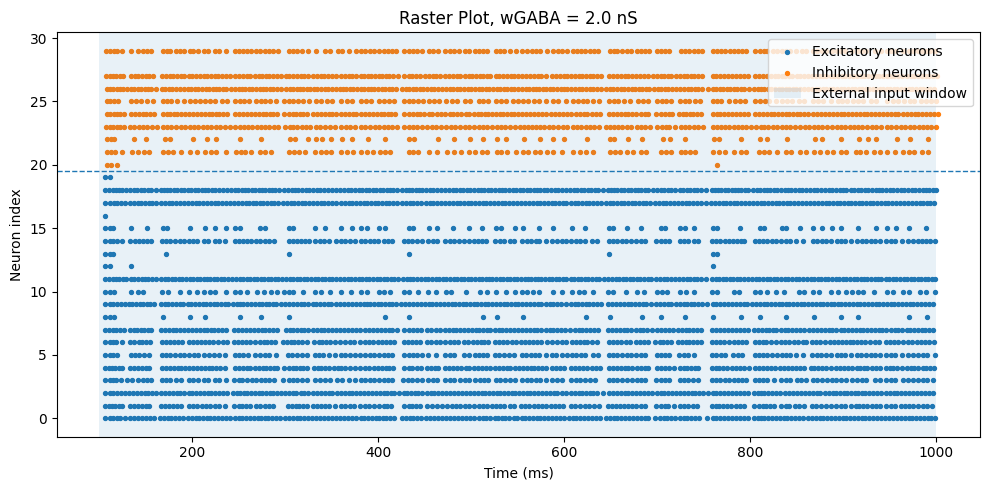

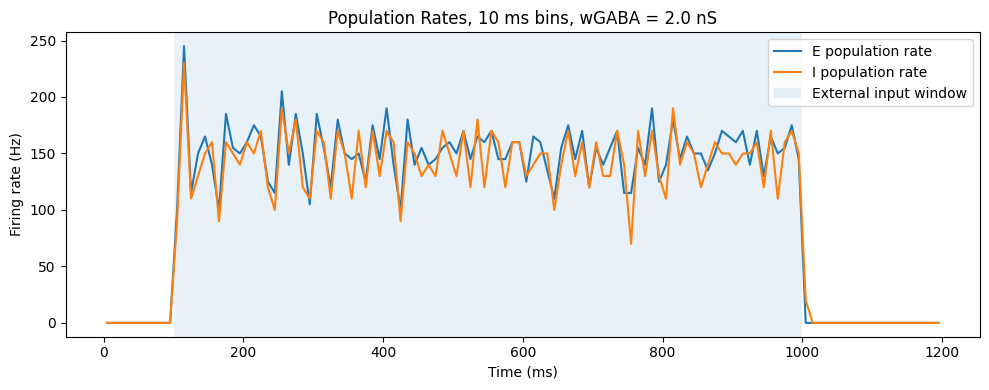

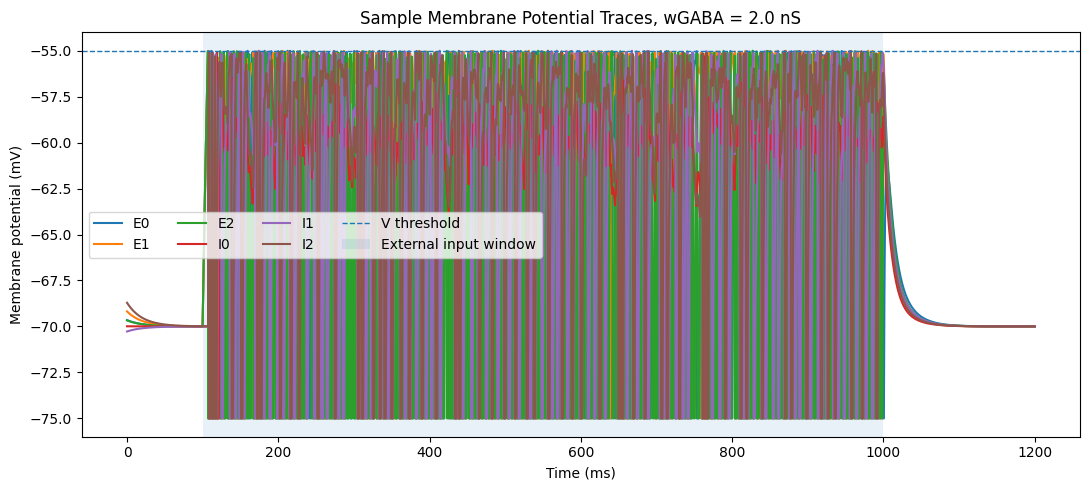

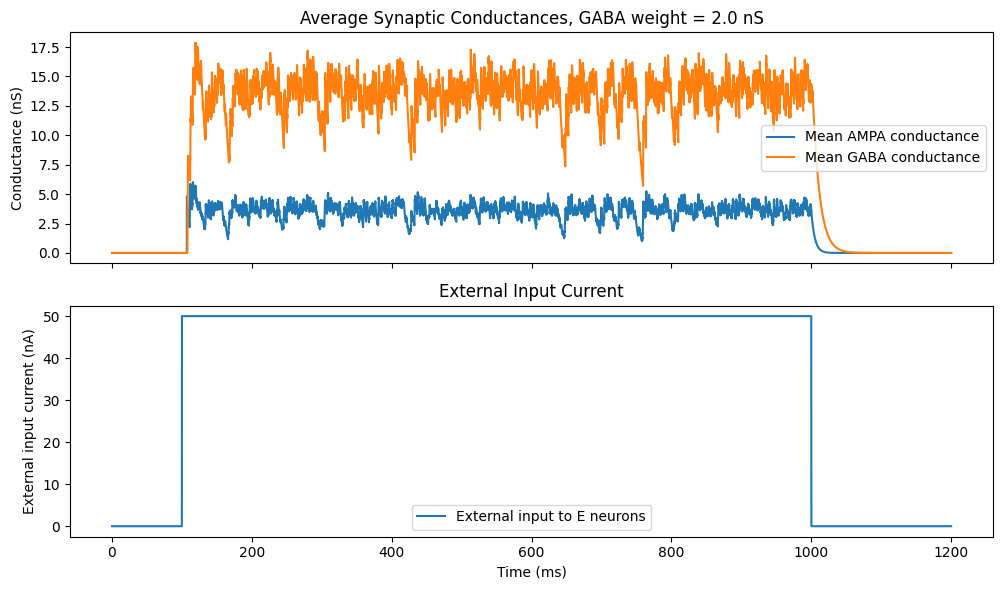

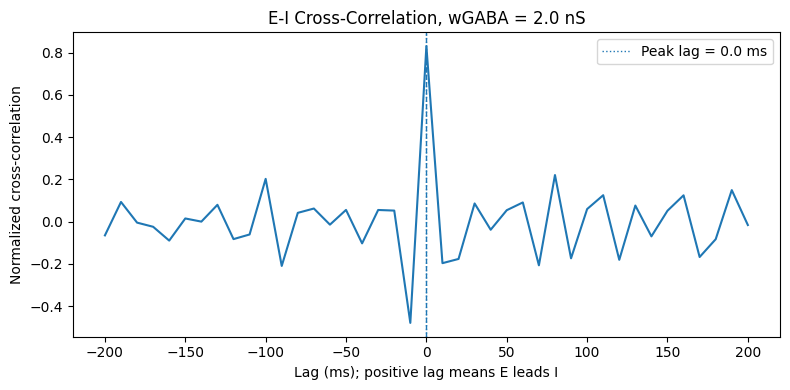

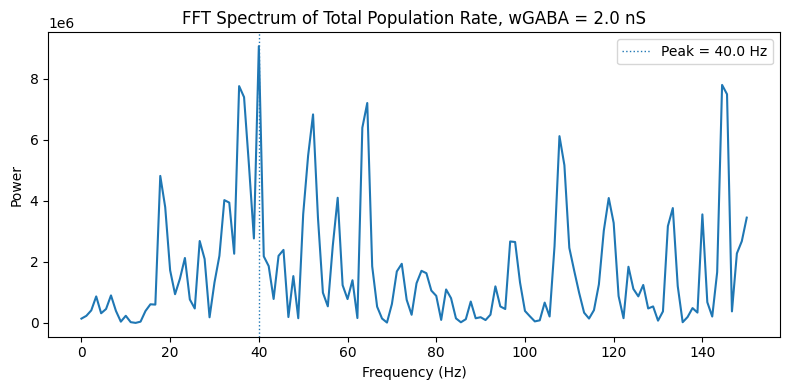

In [66]:
plot_raster(baseline_result)
plot_population_rates(baseline_analysis, baseline_result)
plot_voltage_traces(baseline_result)
plot_conductances_and_input(baseline_result)
plot_cross_correlation(baseline_analysis, baseline_result)
plot_fft_spectrum(baseline_analysis, baseline_result)

### Recurrent recruitment

The saved raster and rate traces show excitatory firing accompanied by recruitment of the inhibitory population. Voltage traces exhibit the implemented spike-and-reset behavior, while increasing AMPA and GABA conductances during stimulation reflect recurrent synaptic activation.


### Baseline measurements

The table below reports stimulation-window firing rates, a population-rate variability measure, the peak cross-correlation and its lag, and the dominant FFT frequency and peak ratio. Together these quantify activity magnitude, temporal coupling, and rhythmic structure.


In [67]:
def summarize_result(result, analysis):
    p = result["params"]

    return {
        "w_GABA_nS": p["w_GABA"],
        "mean_E_rate_Hz": analysis["mean_rate_E"],
        "mean_I_rate_Hz": analysis["mean_rate_I"],
        "synchrony_CV_total_rate": analysis["synchrony_cv"],
        "xcorr_peak_lag_ms": analysis["xcorr"]["peak_lag_ms"],
        "xcorr_peak_value": analysis["xcorr"]["peak_corr"],
        "fft_peak_freq_Hz": analysis["fft"]["peak_freq_hz"],
        "fft_peak_ratio": analysis["fft"]["peak_ratio"],
        "total_spikes": len(result["spike_times"]),
    }


baseline_summary = summarize_result(baseline_result, baseline_analysis)

pd.DataFrame([baseline_summary]).round(3)

,w_GABA_nS,mean_E_rate_Hz,mean_I_rate_Hz,synchrony_CV_total_rate,xcorr_peak_lag_ms,xcorr_peak_value,fft_peak_freq_Hz,fft_peak_ratio,total_spikes
0,2.0,151.833,144.444,0.679,0.0,0.831,40.0,9.254,4035


In [68]:
def print_single_result_interpretation(result, analysis):
    p = result["params"]

    lag = analysis["xcorr"]["peak_lag_ms"]
    peak_corr = analysis["xcorr"]["peak_corr"]

    peak_freq = analysis["fft"]["peak_freq_hz"]
    peak_ratio = analysis["fft"]["peak_ratio"]

    print(f"wGABA = {p['w_GABA']} nS")
    print(f"Mean E rate during input: {analysis['mean_rate_E']:.2f} Hz")
    print(f"Mean I rate during input: {analysis['mean_rate_I']:.2f} Hz")
    print(f"E-I cross-correlation peak lag: {lag:.2f} ms; peak value: {peak_corr:.3f}")

    if np.isfinite(lag):
        if lag > 0:
            print(
                "Interpretation: positive lag means E activity tends to lead I activity, "
                "consistent with excitatory recruitment of inhibitory feedback."
            )
        elif lag < 0:
            print(
                "Interpretation: negative lag means I activity tends to lead E activity, "
                "suggesting dominant inhibitory control or rebound dynamics."
            )
        else:
            print(
                "Interpretation: near-zero lag means E and I population rates are closely synchronized."
            )

    print(f"FFT dominant peak: {peak_freq:.2f} Hz; peak-to-median power ratio: {peak_ratio:.2f}")

    if np.isfinite(peak_ratio) and peak_ratio >= 5:
        print("Interpretation: a clear spectral peak suggests oscillatory population activity.")
    else:
        print(
            "Interpretation: no strong spectral peak suggests more asynchronous-irregular "
            "or weakly rhythmic population activity."
        )


print_single_result_interpretation(baseline_result, baseline_analysis)

wGABA = 2.0 nS
Mean E rate during input: 151.83 Hz
Mean I rate during input: 144.44 Hz
E-I cross-correlation peak lag: 0.00 ms; peak value: 0.831
Interpretation: near-zero lag means E and I population rates are closely synchronized.
FFT dominant peak: 40.00 Hz; peak-to-median power ratio: 9.25
Interpretation: a clear spectral peak suggests oscillatory population activity.


The baseline combines substantial firing with coupled E–I activity. Rates, cross-correlation, and spectra provide complementary evidence; no individual metric fully characterizes the network regime.


### Sensitivity to inhibitory strength

The comparison uses GABA weights of 1.0, 2.0, and 4.0 nS with the same connectivity. The following calculations and figures apply a common set of firing-rate, synchrony, coupling, and spectral measurements to each condition.


In [69]:
def run_parameter_sweep(w_GABA_values=(1.0, 2.0, 4.0), params=None):
    """
    Run simulations for several inhibitory weights.

    The same connectivity and same initial random seed are used across conditions,
    so that differences are mainly attributable to wGABA.
    """
    if params is None:
        params = get_default_params()

    connectivity = create_connectivity(params, seed=params["connectivity_seed"])

    results = {}
    analyses = {}
    rows = []

    for w in w_GABA_values:

        result = simulate_network(
            params,
            connectivity=connectivity,
            w_GABA=w,
            seed=params["simulation_seed"],
        )

        analysis = analyze_result(result)

        results[w] = result
        analyses[w] = analysis

        rows.append(summarize_result(result, analysis))

    summary = pd.DataFrame(rows)

    return results, analyses, summary

In [70]:
def plot_sweep_summary(summary):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(
        summary["w_GABA_nS"],
        summary["mean_E_rate_Hz"],
        marker="o",
        label="E",
    )
    axes[0].plot(
        summary["w_GABA_nS"],
        summary["mean_I_rate_Hz"],
        marker="o",
        label="I",
    )
    axes[0].set_xlabel("wGABA (nS)")
    axes[0].set_ylabel("Mean firing rate during input (Hz)")
    axes[0].set_title("Firing Rate vs Inhibitory Strength")
    axes[0].legend()

    axes[1].plot(
        summary["w_GABA_nS"],
        summary["synchrony_CV_total_rate"],
        marker="o",
    )
    axes[1].set_xlabel("wGABA (nS)")
    axes[1].set_ylabel("CV of total population rate")
    axes[1].set_title("Synchrony/Burstiness Proxy")

    axes[2].plot(
        summary["w_GABA_nS"],
        summary["fft_peak_freq_Hz"],
        marker="o",
    )
    axes[2].set_xlabel("wGABA (nS)")
    axes[2].set_ylabel("Dominant FFT peak (Hz)")
    axes[2].set_title("Oscillation Frequency Estimate")

    plt.tight_layout()
    plt.show()

In [71]:
def plot_sweep_population_rates(analyses, results):
    plt.figure(figsize=(10, 5))

    for w, analysis in analyses.items():
        plt.plot(
            analysis["t_rate"],
            analysis["rate_total_10ms"],
            label=f"wGABA = {w} nS",
        )

    first_result = next(iter(results.values()))
    p = first_result["params"]

    plt.axvspan(p["I_ext_on"], p["I_ext_off"], alpha=0.1, label="External input window")

    plt.xlabel("Time (ms)")
    plt.ylabel("Total population rate (Hz)")
    plt.title("Parameter Sweep: Total Population Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

,w_GABA_nS,mean_E_rate_Hz,mean_I_rate_Hz,synchrony_CV_total_rate,xcorr_peak_lag_ms,xcorr_peak_value,fft_peak_freq_Hz,fft_peak_ratio,total_spikes
0,1.0,321.333,303.778,0.411,0.0,0.801,145.556,11.278,8744
1,2.0,151.833,144.444,0.679,0.0,0.831,40.000,9.254,4035
2,4.0,133.000,79.111,0.617,0.0,0.524,57.778,6.746,3107


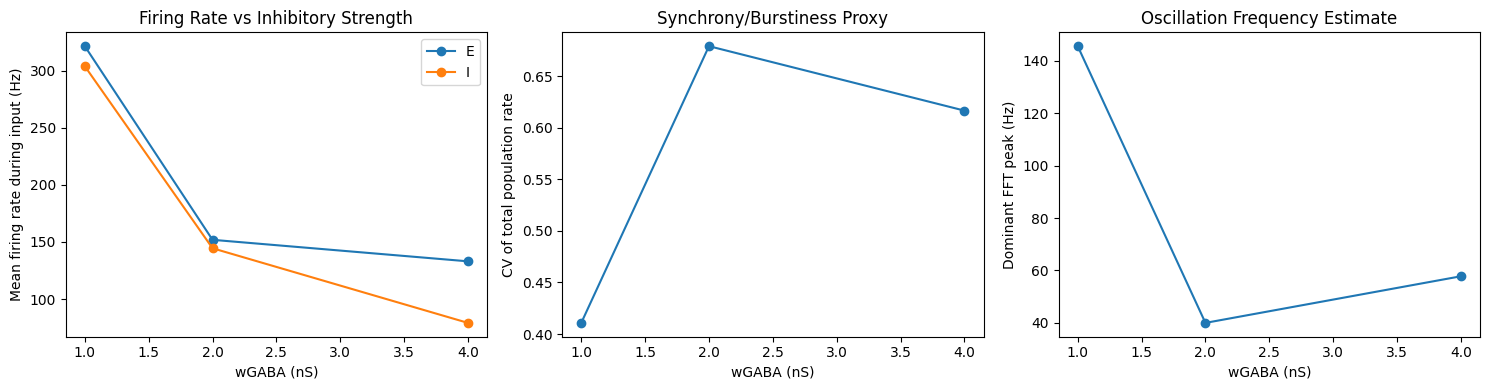

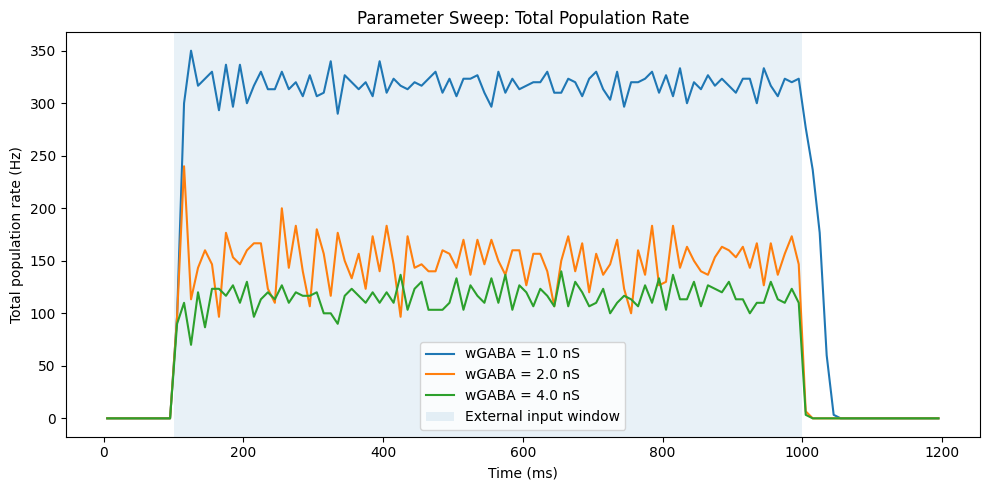

In [72]:
w_GABA_values = [1.0, 2.0, 4.0]

sweep_results, sweep_analyses, sweep_summary = run_parameter_sweep(
    w_GABA_values=w_GABA_values,
    params=params,
)

display(sweep_summary.round(3))

plot_sweep_summary(sweep_summary)
plot_sweep_population_rates(sweep_analyses, sweep_results)

The parameter sweep shows that inhibitory feedback changes both the magnitude and timing of recurrent activity. The weak-inhibition condition permits especially strong excitation; increasing inhibition reduces firing and changes the spectral pattern.


### Comparing network regimes

Aligned raster and rate plots expose changes in firing intensity across conditions. The corresponding cross-correlations show E–I coordination, and FFT spectra show how the dominant rhythmic component shifts with inhibitory strength.


Detailed plots for wGABA = 1.0 nS


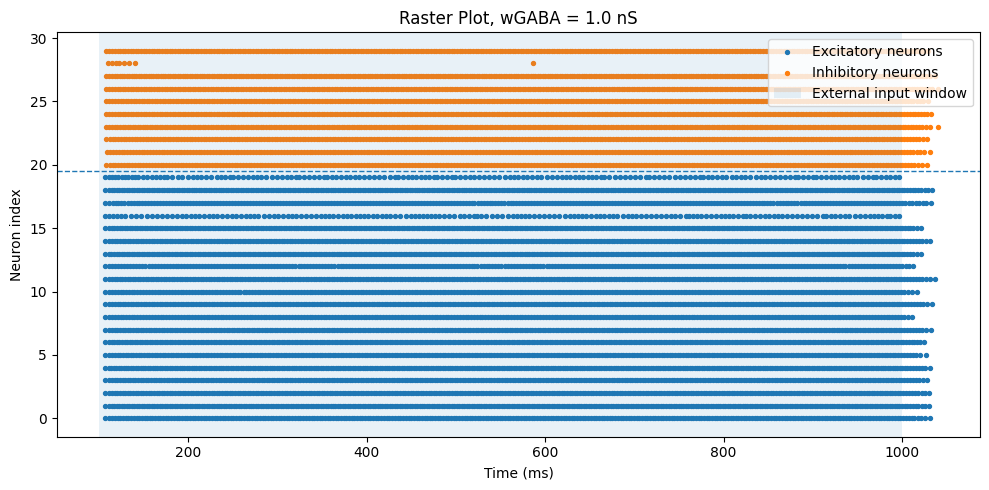

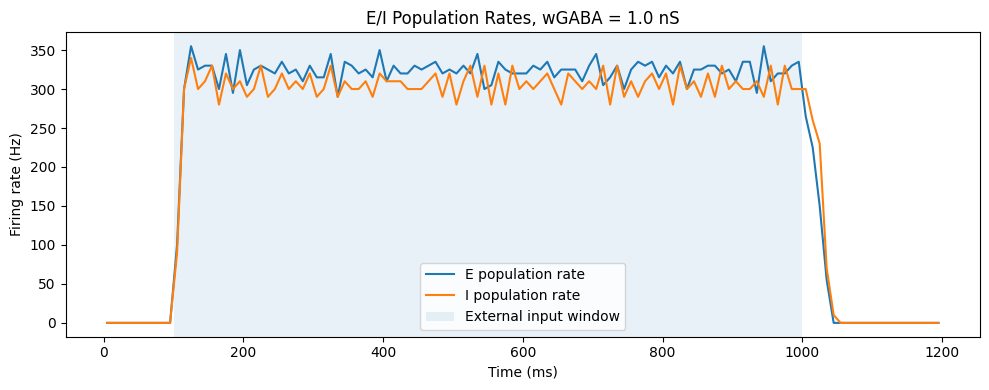

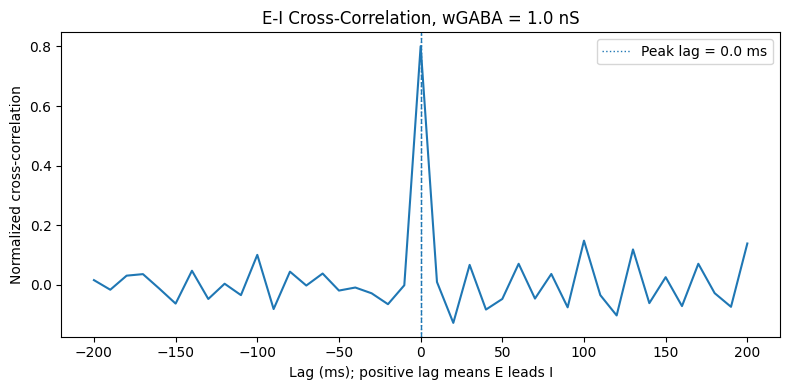

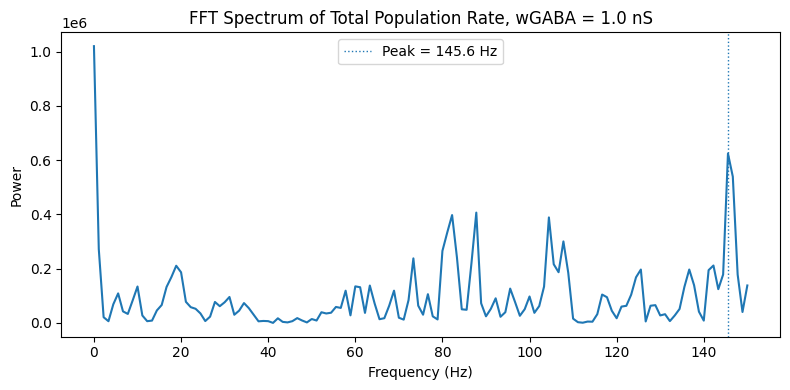

Detailed plots for wGABA = 2.0 nS


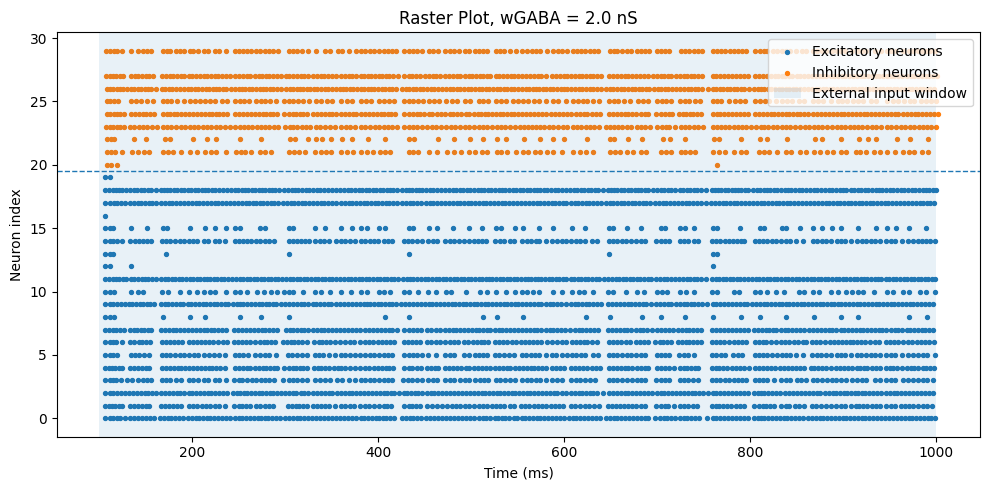

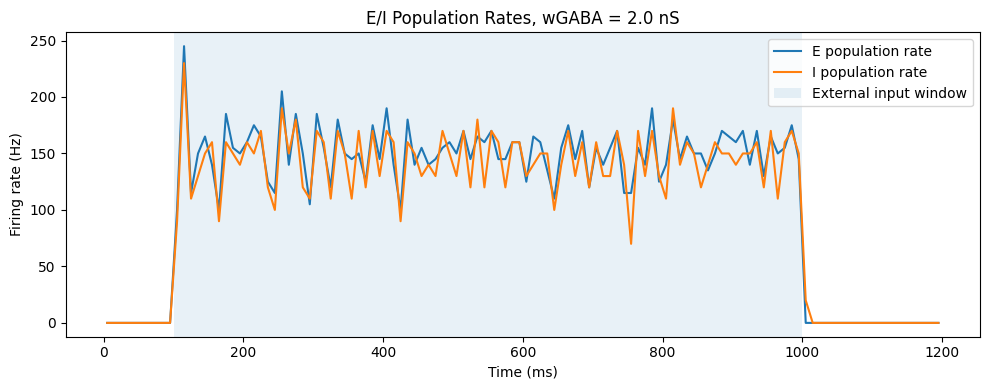

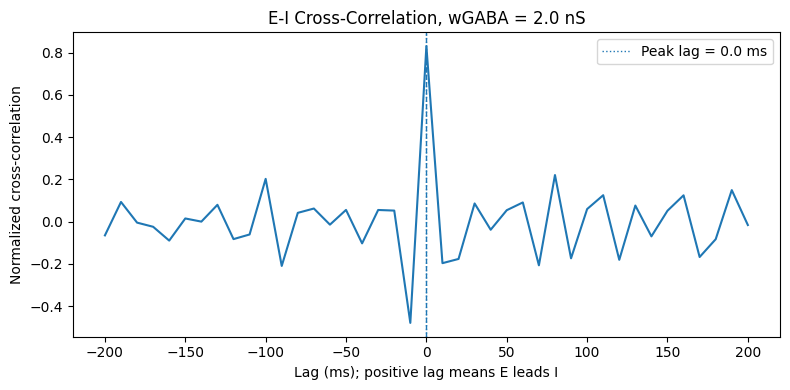

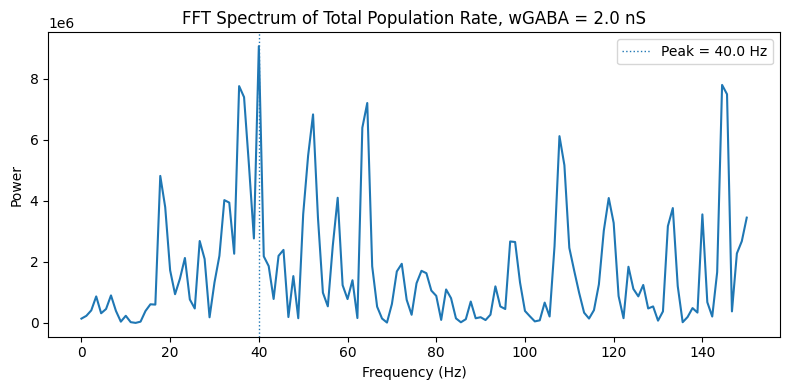

Detailed plots for wGABA = 4.0 nS


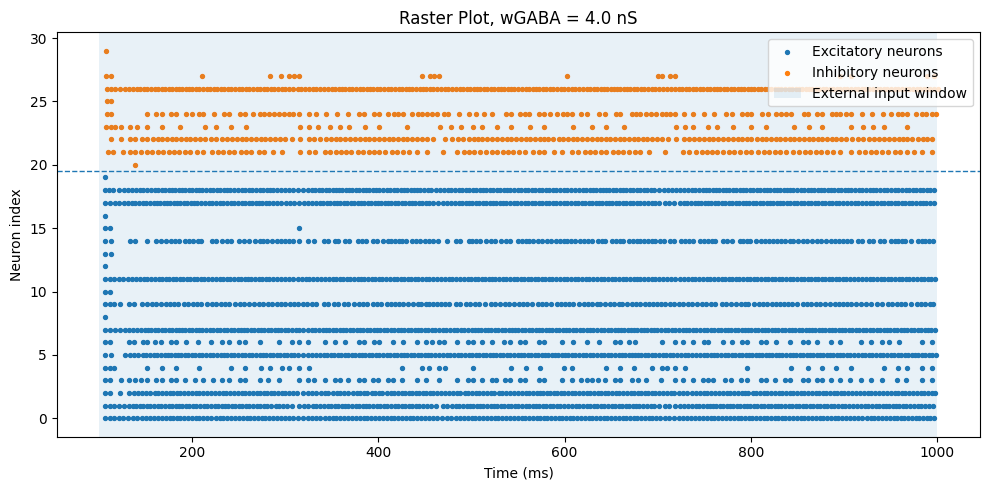

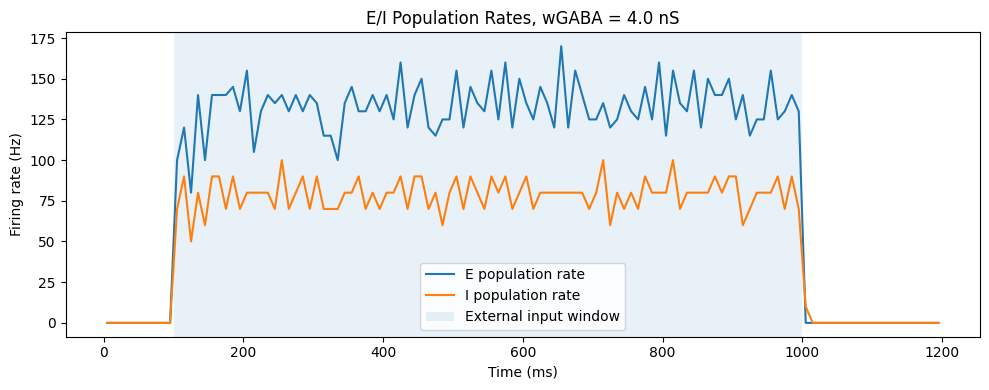

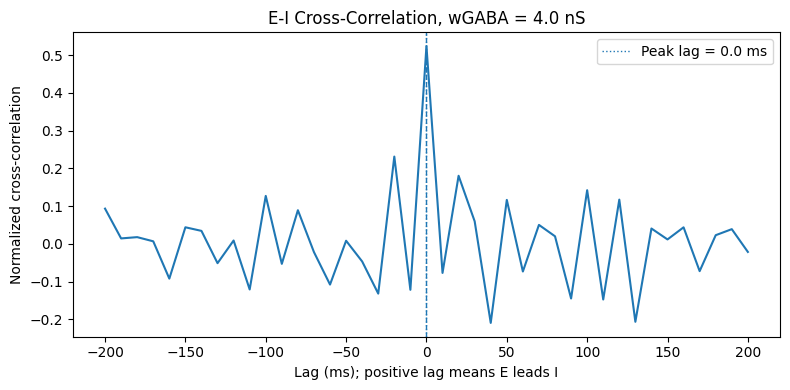

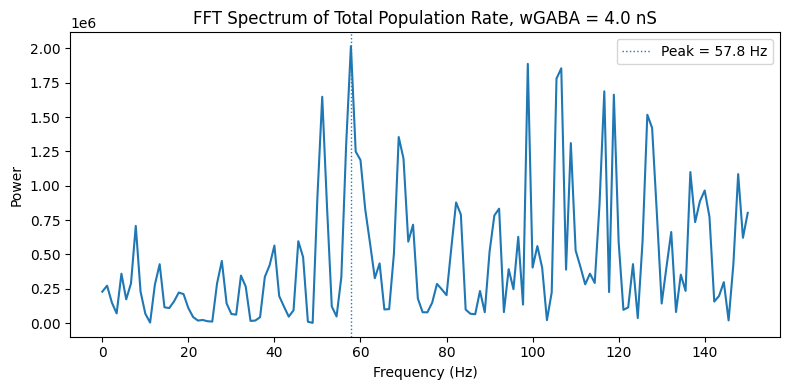

In [73]:
for w in w_GABA_values:
    print(f"Detailed plots for wGABA = {w} nS")

    result = sweep_results[w]
    analysis = sweep_analyses[w]

    plot_raster(result, title=f"Raster Plot, wGABA = {w} nS")
    plot_population_rates(analysis, result, title=f"E/I Population Rates, wGABA = {w} nS")
    plot_cross_correlation(analysis, result)
    plot_fft_spectrum(analysis, result)

The saved comparisons support a progression from excessive recurrent firing under weak inhibition to lower activity under stronger inhibition. Moderate inhibition retains a prominent rhythmic component. Firing intensity and temporal organization therefore both contribute to the interpretation.


### Quantitative interpretation

| GABA weight (nS) | Mean E firing rate (Hz) | Mean I firing rate (Hz) |
| --- | ---: | ---: |
| 1.0 | 321.33 | 303.78 |
| 2.0 | 151.83 | 144.44 |
| 4.0 | 133.00 | 79.11 |

At 1.0 nS, recurrent excitation produces very high firing rates. This condition provides a weak-inhibition reference. Raising the weight to 2.0 nS reduces both population rates and produces a dominant spectral peak around 40 Hz, consistent with a gamma-range-like component in the model's activity.

At 4.0 nS, both populations fire less, with a particularly large reduction in inhibitory activity. Because inhibitory neurons receive no direct external current, reduced excitatory activity can weaken their recruitment. Recurrent inhibition within the inhibitory population may also contribute.

Cross-correlation peaks near zero lag at 10 ms resolution, supporting tight E–I coordination. The weak-inhibition spectrum contains a high-frequency peak associated with excessive recurrent activity; the moderate condition has the clearest approximately 40 Hz component; stronger inhibition shifts the dominant peak and reduces firing.

The relative comparison illustrates the sensitivity of recurrent population dynamics to inhibitory feedback. It is consistent with a role for E/I balance in regulating cortical activity and with PING-like recurrent interaction within the model.

## Limitations

The absolute firing rates are high relative to typical physiological values, particularly under weak inhibition. The network is small, uses shared LIF parameters and random connectivity, and does not explicitly model synaptic delays. Its results support comparisons between parameter settings rather than precise reproduction of biological firing rates.

Ten-millisecond correlation bins cannot resolve a lead of only a few milliseconds. Near-zero lag and a gamma-range spectral peak do not establish a complete PING mechanism. The synchrony statistic is a population-rate proxy and should be interpreted alongside the raster and rate plots.

Figures and numerical outputs retain the saved execution. This portfolio revision changes the narrative; it does not represent a new simulation run.
